# Tree Experiments

Example notebook for exploring two topics related to decision trees:
* methods for generating visual representations of decision trees in Python.
* the influence of hyperparameters on tree building, including aspects such as accuracy, tree size, and overfitting

Ricardo Almeida, based on [Visualize a Decision Tree in 4 Ways with Scikit-Learn and Python](https://mljar.com/blog/visualize-decision-tree/) by Piotr Płoński

In [1]:
# Additional requirements
# pip install dtreeviz

### Training and Visualization

In [2]:
from matplotlib import pyplot as plt
from sklearn import datasets
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import train_test_split

In [35]:
RANDOM_SEED = 7657

TEST_SIZE=0.10

Prepare the data

In [36]:
iris = datasets.load_iris()

In [37]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [38]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [39]:
X = iris.data
y = iris.target

In [40]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=RANDOM_SEED, test_size=TEST_SIZE)

Decide on model parameters

In [42]:
MAX_DEPTH = 7
MIN_SAMPLES_LEAF = 1
MIN_SAMPLE_SPLIT = 2

Fit the model

In [43]:
model = DecisionTreeClassifier(random_state=RANDOM_SEED,
                               max_depth=MAX_DEPTH,
                               min_samples_leaf=MIN_SAMPLES_LEAF,
                               min_samples_split=MIN_SAMPLE_SPLIT)

In [44]:
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,7657
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Check performance

In [45]:
accuracy_train = model.score(X_train, y_train)*100
accuracy_test  = model.score(X_test, y_test)*100

print("Accuracy on train set:  {:.1f}%".format(accuracy_train))
print("Accuracy on test  set:  {:.1f}%".format(accuracy_test))

Accuracy on train set:  100.0%
Accuracy on test  set:  93.3%


#### 1. Visualization: as text

In [46]:
text_representation = tree.export_text(model)
print(text_representation)

|--- feature_3 <= 0.80
|   |--- class: 0
|--- feature_3 >  0.80
|   |--- feature_3 <= 1.75
|   |   |--- feature_2 <= 4.95
|   |   |   |--- feature_3 <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- feature_3 >  1.65
|   |   |   |   |--- class: 2
|   |   |--- feature_2 >  4.95
|   |   |   |--- feature_3 <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- feature_3 >  1.55
|   |   |   |   |--- feature_2 <= 5.45
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- feature_2 >  5.45
|   |   |   |   |   |--- class: 2
|   |--- feature_3 >  1.75
|   |   |--- class: 2



#### 2. Visualization: matplotlib

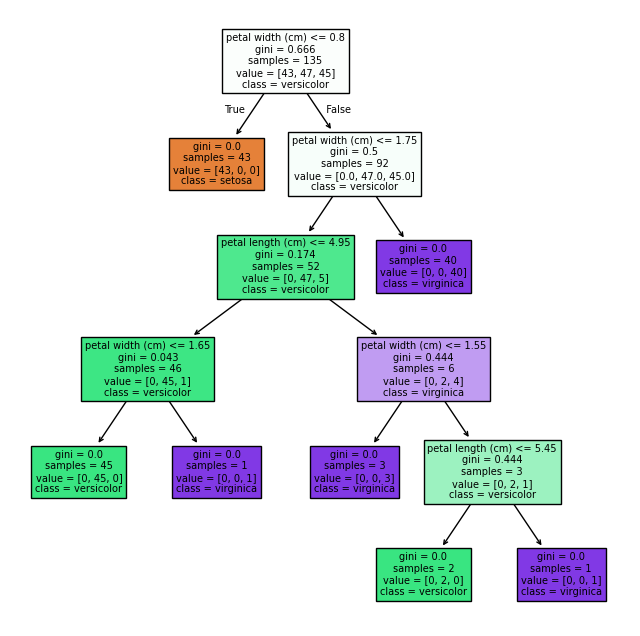

In [47]:
fig = plt.figure(figsize=(8,8))
_ = tree.plot_tree(model, 
                   feature_names=iris.feature_names,  
                   class_names=list(iris.target_names),
                   filled=True)

#### 3. Visualization: graphviz

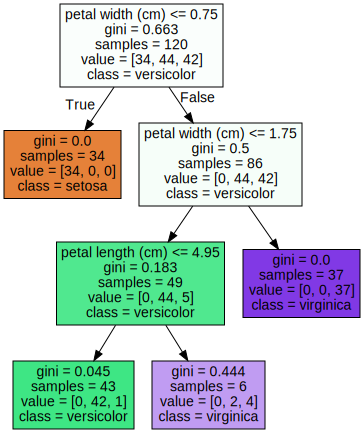

In [21]:
import graphviz

dot_data = tree.export_graphviz(model, out_file=None, 
                                feature_names=iris.feature_names,  
                                class_names=iris.target_names,
                                filled=True)

# Draw graph
graph = graphviz.Source(dot_data, format="png") 
graph

#### 4. Visualization: dtreeviz

In [22]:
import dtreeviz.trees

In [23]:
viz = dtreeviz.model(model, X_train, y_train,
                target_name="target",
                feature_names=iris.feature_names,
                class_names=list(iris.target_names))

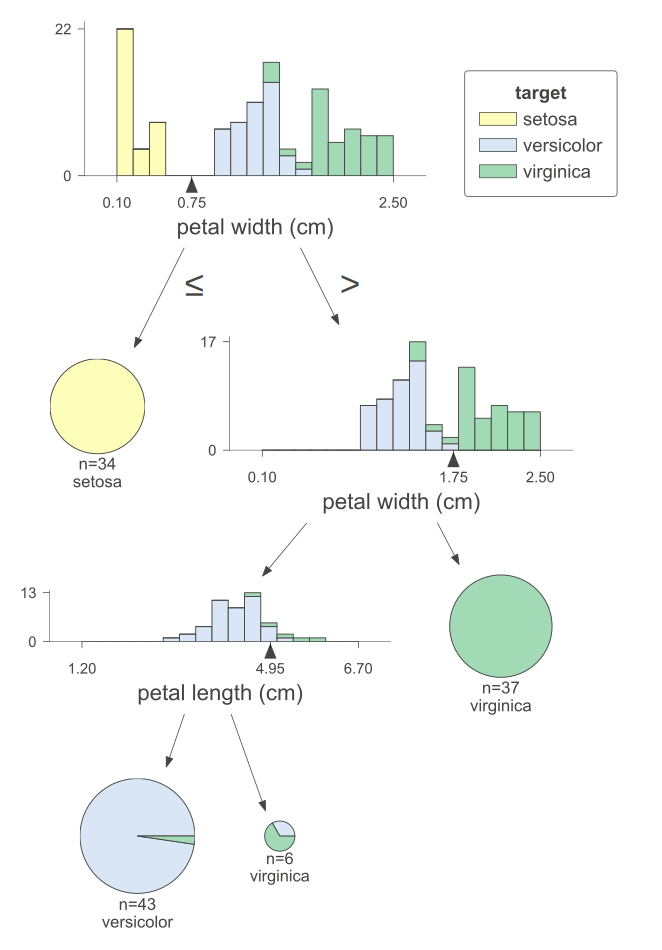

In [24]:
viz.view(scale=2.5)